# Sales Data Analysis Using SQL & Python

This project analyzes retail sales data using SQL queries integrated with Python to extract business insights.

In [26]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [27]:
df = pd.read_csv("../data/superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Data Cleaning & Preparation

In [28]:
df.columns = df.columns.str.replace(" ", "_")

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Year_Month'] = df['Order_Date'].dt.strftime('%Y-%m')
conn = sqlite3.connect("sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

9800

## SQL Analysis

### Revenue by Region

In [29]:
query = """
SELECT Region, SUM(Sales) AS Revenue
FROM sales
GROUP BY Region
ORDER BY Revenue DESC;
"""

region_sales = pd.read_sql(query, conn)
region_sales

,Region,Revenue
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


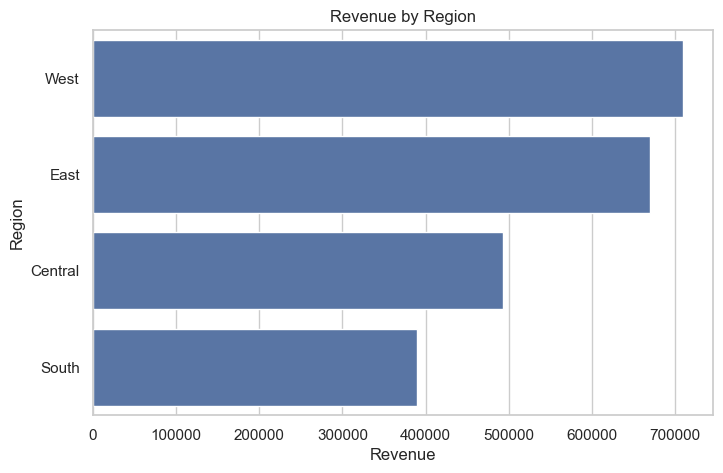

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x="Revenue", y="Region")
plt.title("Revenue by Region")
plt.show()

**Insight:**
- West region generates the highest revenue.
- Certain regions significantly outperform others.

### Top 10 Customers by Revenue

In [31]:
query = """
SELECT Region, SUM(Sales) AS Revenue
FROM sales
GROUP BY Region
ORDER BY Revenue DESC;
"""

region_sales = pd.read_sql(query, conn)
region_sales

,Region,Revenue
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


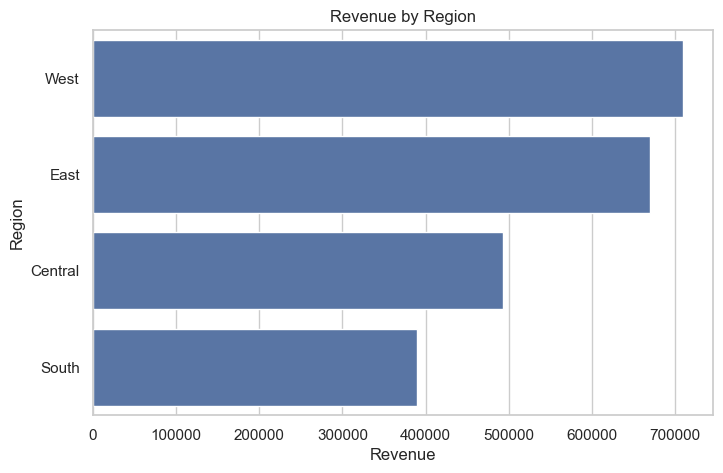

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x="Revenue", y="Region")
plt.title("Revenue by Region")
plt.savefig("../images/revenue_by_region.png")
plt.show()

### Top 10 Customers by Revenue

In [33]:
query = """
SELECT Customer_Name, SUM(Sales) AS Total_Spent
FROM sales
GROUP BY Customer_Name
ORDER BY Total_Spent DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)
top_customers

,Customer_Name,Total_Spent
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


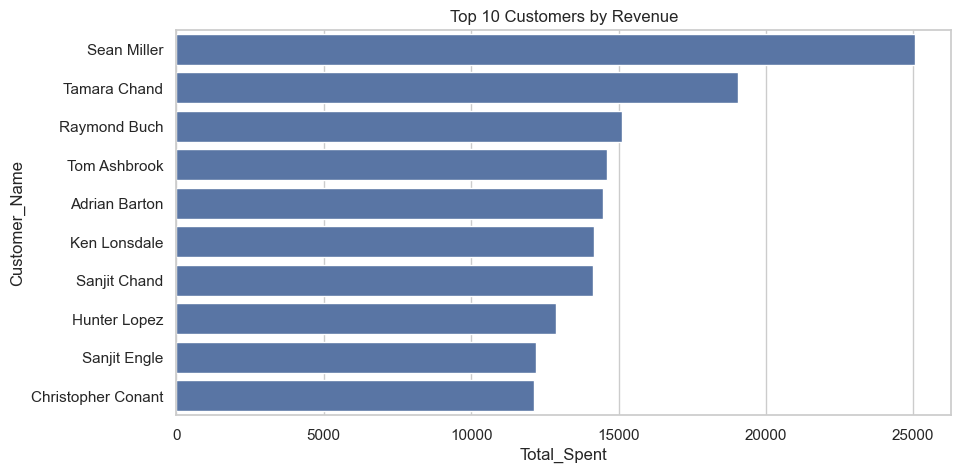

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_customers, x="Total_Spent", y="Customer_Name")
plt.title("Top 10 Customers by Revenue")
plt.savefig("../images/top_customers.png")
plt.show()

**Insight:**
- A small group of customers contributes significantly to total revenue.
- Indicates possible high-value client segment.

### Monthly Sales Trend

In [35]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Year_Month'] = df['Order_Date'].dt.strftime('%Y-%m')
df.to_sql("sales", conn, if_exists="replace", index=False)

9800

In [36]:
query = """
SELECT Year_Month, SUM(Sales) AS Monthly_Revenue
FROM sales
GROUP BY Year_Month
ORDER BY Year_Month;
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales

,Year_Month,Monthly_Revenue
0,2015-01,14205.7070
1,2015-02,4519.8920
2,2015-03,55205.7970
3,2015-04,27906.8550
4,2015-05,23644.3030
5,2015-06,34322.9356
6,2015-07,33781.5430
7,2015-08,27117.5365
8,2015-09,81623.5268
9,2015-10,31453.3930


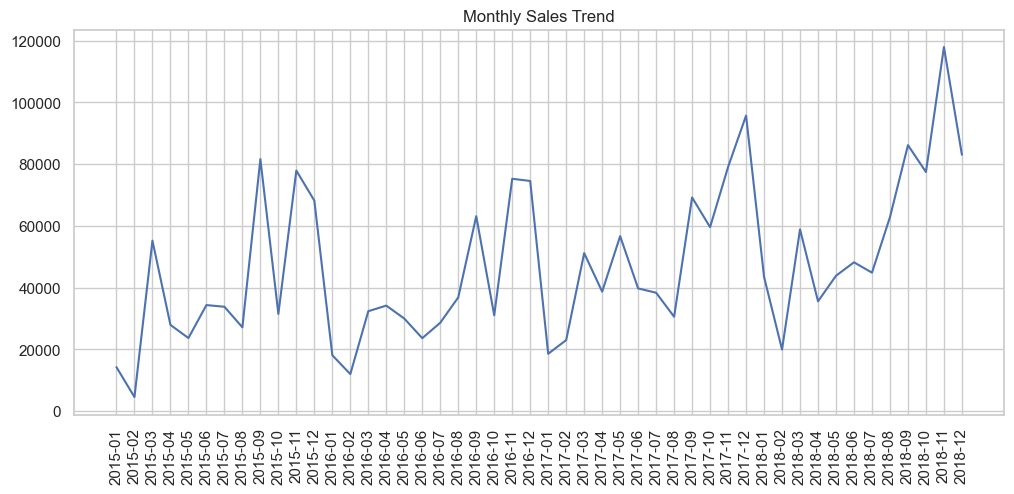

In [37]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Year_Month'], monthly_sales['Monthly_Revenue'])
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.savefig("../images/monthly_sales_trend.png")
plt.show()

**Insight:**
- Sales show clear growth trend over time.
- Certain months show seasonal peaks.
- Suggests strong periodic demand patterns.

## Final Business Recommendations

- Strengthen retention strategies for top customers.
- Focus marketing investments in high-performing regions.
- Investigate reasons behind lower-performing regions.
- Use seasonal trends for better inventory and planning decisions.